# IEMOCAP — EDA, Quick Emotion Classifier & Inference

This notebook works directly with the **already provided IEMOCAP pickle files** in Google Drive.

### Workflow
1. Load `iemocap_data.pkl` and `iemocap_data_noalign.pkl`
2. Inspect structure, keys, shapes and data types
3. Perform basic statistics and EDA
4. Analyse emotion/class distribution
5. Compare aligned and no-align representations
6. Train a quick **TF-IDF + Logistic Regression** emotion baseline when raw text is available
7. Evaluate using accuracy, weighted F1, classification report and confusion matrix
8. Perform inference on new sentences

> **Note:** IEMOCAP is an emotion-recognition dataset, so the classifier is referred to as an **emotion classifier** rather than a sentiment classifier.


## 0. Imports and setup

In [1]:
# ================================================================

import os
import pickle
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)


warnings.filterwarnings("ignore")

print("=" * 80)
print("IEMOCAP EDA + QUICK EMOTION CLASSIFIER")
print("=" * 80)

IEMOCAP EDA + QUICK EMOTION CLASSIFIER


## 1. Mount Google Drive

In [2]:
# ================================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Google Colab Drive mount was not available.")
    print("If running outside Colab, make sure DATA_DIR points to your files.")

Mounted at /content/drive


## 2. File paths

In [3]:
# ================================================================

DATA_DIR = "/content/drive/MyDrive/IEMOCAP"

ALIGN_PATH = os.path.join(DATA_DIR, "iemocap_data.pkl")
NOALIGN_PATH = os.path.join(DATA_DIR, "iemocap_data_noalign.pkl")

print("\nData directory:")
print(DATA_DIR)

print("\nChecking files...")
print("Aligned file  :", ALIGN_PATH)
print("Exists        :", os.path.exists(ALIGN_PATH))
print("No-align file :", NOALIGN_PATH)
print("Exists        :", os.path.exists(NOALIGN_PATH))

if not os.path.exists(ALIGN_PATH):
    raise FileNotFoundError(
        f"\nAligned pickle was not found:\n{ALIGN_PATH}\n"
        "Check the folder/file name in Google Drive."
    )

if not os.path.exists(NOALIGN_PATH):
    print(
        "\nWARNING: no-align pickle was not found.\n"
        "The analysis will continue with the aligned file only."
    )


Data directory:
/content/drive/MyDrive/IEMOCAP

Checking files...
Aligned file  : /content/drive/MyDrive/IEMOCAP/iemocap_data.pkl
Exists        : True
No-align file : /content/drive/MyDrive/IEMOCAP/iemocap_data_noalign.pkl
Exists        : True


## 3. Load pickle files

In [4]:
# ================================================================

print("\n" + "=" * 80)
print("LOADING PICKLE FILES")
print("=" * 80)

with open(ALIGN_PATH, "rb") as f:
    aligned_data = pickle.load(f)

if os.path.exists(NOALIGN_PATH):
    with open(NOALIGN_PATH, "rb") as f:
        noalign_data = pickle.load(f)
else:
    noalign_data = None

print("\nAligned object type :", type(aligned_data))
print("No-align object type:", type(noalign_data))


LOADING PICKLE FILES

Aligned object type : <class 'dict'>
No-align object type: <class 'dict'>


In [5]:
OUTPUT_DIR = "/content/drive/MyDrive/mplmm_final_deliverables/outputs/IEMOCAP"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Visual outputs:", OUTPUT_DIR)


Visual outputs: /content/drive/MyDrive/mplmm_final_deliverables/outputs/IEMOCAP


## 4. Normalize pickle keys

In [6]:
# ================================================================

def normalize_keys(obj):
    """
    Recursively convert dictionary byte keys such as b'train'
    into normal strings such as 'train'.
    """
    if isinstance(obj, dict):
        new_obj = {}
        for key, value in obj.items():
            if isinstance(key, bytes):
                try:
                    key = key.decode("utf-8")
                except Exception:
                    pass
            new_obj[key] = normalize_keys(value)
        return new_obj

    if isinstance(obj, list):
        return [normalize_keys(x) for x in obj]

    if isinstance(obj, tuple):
        return tuple(normalize_keys(x) for x in obj)

    return obj


aligned_data = normalize_keys(aligned_data)

if noalign_data is not None:
    noalign_data = normalize_keys(noalign_data)

## 5. Helper functions

In [7]:
# ================================================================

def safe_shape(value):
    """Return shape if possible."""
    try:
        return np.asarray(value).shape
    except Exception:
        return None


def value_length(value):
    """Return first dimension/length where possible."""
    try:
        return len(value)
    except Exception:
        return None


def describe_value(value):
    """Short description of an object."""
    info = {
        "Type": type(value).__name__,
        "Shape": safe_shape(value),
        "Length": value_length(value)
    }

    if isinstance(value, pd.DataFrame):
        info["Columns"] = list(value.columns)

    return info


def inspect_structure(obj, name="root", level=0, max_level=3):
    """
    Print nested pickle structure without dumping the entire dataset.
    """
    indent = "  " * level

    print(f"{indent}{name}: {type(obj).__name__}")

    if level >= max_level:
        return

    if isinstance(obj, dict):
        keys = list(obj.keys())
        print(f"{indent}Keys: {keys[:30]}")

        for key in keys[:15]:
            inspect_structure(
                obj[key],
                str(key),
                level + 1,
                max_level
            )

    elif isinstance(obj, (list, tuple)):
        print(f"{indent}Length: {len(obj)}")

        if len(obj) > 0:
            inspect_structure(
                obj[0],
                "[0]",
                level + 1,
                max_level
            )

    elif isinstance(obj, np.ndarray):
        print(
            f"{indent}Shape: {obj.shape} | "
            f"Dtype: {obj.dtype}"
        )

    elif isinstance(obj, pd.DataFrame):
        print(f"{indent}Shape: {obj.shape}")
        print(f"{indent}Columns: {list(obj.columns)}")


def get_split(data, possible_names):
    """Find train/validation/test split under several possible names."""
    if not isinstance(data, dict):
        return None, None

    for name in possible_names:
        if name in data:
            return data[name], name

    # Case-insensitive fallback
    lower_map = {str(k).lower(): k for k in data.keys()}

    for name in possible_names:
        if name.lower() in lower_map:
            actual_key = lower_map[name.lower()]
            return data[actual_key], actual_key

    return None, None


def get_split_data(data, split_name):
    """
    Return a split using common names.
    """
    if split_name == "train":
        names = ["train", "training"]
    elif split_name == "valid":
        names = ["valid", "validation", "val", "dev"]
    elif split_name == "test":
        names = ["test", "testing"]
    else:
        names = [split_name]

    return get_split(data, names)


def find_key(container, candidates):
    """
    Find a key in a dictionary using exact and case-insensitive matching.
    """
    if not isinstance(container, dict):
        return None

    for candidate in candidates:
        if candidate in container:
            return candidate

    lower_map = {
        str(k).lower(): k
        for k in container.keys()
    }

    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]

    return None


def find_text_key(split_data):
    """
    Find likely raw text/transcript field.
    Preference is given to actual strings rather than embeddings.
    """
    if not isinstance(split_data, dict):
        return None

    candidates = [
        "raw_text",
        "text",
        "transcript",
        "transcripts",
        "utterance",
        "utterances",
        "sentence",
        "sentences",
        "text_raw"
    ]

    # First find candidate keys
    candidate_keys = []

    for candidate in candidates:
        key = find_key(split_data, [candidate])
        if key is not None and key not in candidate_keys:
            candidate_keys.append(key)

    # Prefer a candidate containing actual strings
    for key in candidate_keys:
        value = split_data[key]

        try:
            arr = np.asarray(value, dtype=object).reshape(-1)
            if len(arr) > 0:
                sample = arr[:min(20, len(arr))]
                string_count = sum(
                    isinstance(x, str)
                    for x in sample
                )

                if string_count >= max(1, len(sample) // 2):
                    return key
        except Exception:
            pass

    return candidate_keys[0] if candidate_keys else None


def find_label_key(split_data):
    """
    Find the most likely emotion/classification label key.
    """
    if not isinstance(split_data, dict):
        return None

    candidates = [
        "classification_labels",
        "classification_label",
        "emotion_labels",
        "emotion_label",
        "labels",
        "label",
        "emotion",
        "emotions",
        "sentiment",
        "sentiment_labels",
        "y"
    ]

    return find_key(split_data, candidates)


def extract_array(value):
    """
    Convert common list/array-like values into numpy array.
    """
    if isinstance(value, np.ndarray):
        return value
    return np.asarray(value)


def flatten_labels(labels):
    """
    Flatten labels while preserving common scalar/string labels.
    """
    arr = np.asarray(labels)

    if arr.ndim == 0:
        return np.asarray([arr.item()])

    if arr.ndim > 1:
        # Typical case: (N, 1)
        if arr.shape[-1] == 1:
            arr = arr.reshape(-1)

    return arr


def clean_text_array(values):
    """
    Convert text values to strings and replace missing values.
    """
    cleaned = []

    for value in list(values):
        if value is None:
            cleaned.append("")
        elif isinstance(value, float) and np.isnan(value):
            cleaned.append("")
        else:
            cleaned.append(str(value))

    return np.asarray(cleaned, dtype=object)


def first_numeric_array(split_data, exclude_keys=None):
    """
    Find a numeric array suitable for a fallback classifier.
    This is only used if raw text is unavailable.
    """
    if not isinstance(split_data, dict):
        return None, None

    exclude_keys = set(
        x.lower()
        for x in (exclude_keys or [])
    )

    preferred = [
        "text",
        "text_features",
        "text_feature",
        "text_bert",
        "bert",
        "language",
        "linguistic"
    ]

    # First search preferred names
    keys_to_try = []

    for name in preferred:
        key = find_key(split_data, [name])
        if key is not None and key not in keys_to_try:
            keys_to_try.append(key)

    # Then search remaining keys
    for key in split_data.keys():
        if key not in keys_to_try:
            keys_to_try.append(key)

    for key in keys_to_try:
        if str(key).lower() in exclude_keys:
            continue

        try:
            arr = np.asarray(split_data[key])

            if not np.issubdtype(arr.dtype, np.number):
                continue

            if arr.ndim < 2:
                continue

            # Ignore likely label-like arrays
            if arr.ndim == 1:
                continue

            return key, arr

        except Exception:
            continue

    return None, None


def temporal_mean_pool(arr):
    """
    Convert a 3D sequence representation
    (N, T, D) -> (N, D).

    If already (N, D), keep unchanged.
    """
    arr = np.asarray(arr)

    if arr.ndim == 3:
        return np.nanmean(arr, axis=1)

    if arr.ndim == 2:
        return arr

    if arr.ndim > 3:
        # Flatten all dimensions after sample dimension.
        return arr.reshape(arr.shape[0], -1)

    return arr.reshape(arr.shape[0], -1)


def print_dataset_summary(data, dataset_name):
    """
    Print splits, keys, shapes and basic numeric statistics.
    """
    print("\n" + "=" * 80)
    print(f"{dataset_name.upper()} - DATASET SUMMARY")
    print("=" * 80)

    if not isinstance(data, dict):
        print("Dataset is not a dictionary.")
        return

    print("\nTop-level keys:")
    print(list(data.keys()))

    for logical_split in ["train", "valid", "test"]:

        split_data, actual_name = get_split_data(
            data,
            logical_split
        )

        if split_data is None:
            continue

        print("\n" + "-" * 80)
        print(
            f"{logical_split.upper()} "
            f"(stored as: {actual_name})"
        )
        print("-" * 80)

        if not isinstance(split_data, dict):
            print("Split type:", type(split_data))
            print("Shape/length:", safe_shape(split_data))
            continue

        rows = []

        for key, value in split_data.items():

            arr_shape = safe_shape(value)

            rows.append({
                "Feature / Column": key,
                "Type": type(value).__name__,
                "Shape": str(arr_shape),
                "Length": value_length(value)
            })

        display(pd.DataFrame(rows))

        # Numeric basic stats
        numeric_rows = []

        for key, value in split_data.items():

            try:
                arr = np.asarray(value)

                if not np.issubdtype(arr.dtype, np.number):
                    continue

                numeric_rows.append({
                    "Feature": key,
                    "Shape": str(arr.shape),
                    "Min": np.nanmin(arr),
                    "Max": np.nanmax(arr),
                    "Mean": np.nanmean(arr),
                    "Std": np.nanstd(arr),
                    "NaN Count": np.isnan(arr).sum(),
                    "Inf Count": np.isinf(arr).sum()
                })

            except Exception:
                continue

        if numeric_rows:
            print("\nNumeric feature statistics:")
            display(pd.DataFrame(numeric_rows))


def split_size(data, logical_split):
    """
    Get sample count for a split.
    """
    split_data, _ = get_split_data(
        data,
        logical_split
    )

    if split_data is None:
        return None

    if isinstance(split_data, dict):

        # Prefer labels/text/modality length
        preferred_keys = [
            "classification_labels",
            "labels",
            "label",
            "emotion",
            "text",
            "raw_text",
            "audio",
            "vision",
            "visual"
        ]

        key = find_key(
            split_data,
            preferred_keys
        )

        if key is not None:
            return value_length(split_data[key])

        for value in split_data.values():
            n = value_length(value)
            if n is not None:
                return n

    return value_length(split_data)

## 6. Inspect pickle structure

In [8]:
# ================================================================

print("\n" + "=" * 80)
print("ALIGNED PICKLE STRUCTURE")
print("=" * 80)

inspect_structure(
    aligned_data,
    max_level=3
)

if noalign_data is not None:
    print("\n" + "=" * 80)
    print("NO-ALIGN PICKLE STRUCTURE")
    print("=" * 80)

    inspect_structure(
        noalign_data,
        max_level=3
    )


ALIGNED PICKLE STRUCTURE
root: dict
Keys: ['test', 'train', 'valid']
  test: dict
  Keys: ['labels', 'text', 'audio', 'vision']
    labels: ndarray
    Shape: (938, 4, 2) | Dtype: int64
    text: ndarray
    Shape: (938, 20, 300) | Dtype: float64
    audio: ndarray
    Shape: (938, 20, 74) | Dtype: float64
    vision: ndarray
    Shape: (938, 20, 35) | Dtype: float64
  train: dict
  Keys: ['labels', 'text', 'audio', 'vision']
    labels: ndarray
    Shape: (2717, 4, 2) | Dtype: int64
    text: ndarray
    Shape: (2717, 20, 300) | Dtype: float64
    audio: ndarray
    Shape: (2717, 20, 74) | Dtype: float64
    vision: ndarray
    Shape: (2717, 20, 35) | Dtype: float64
  valid: dict
  Keys: ['labels', 'text', 'audio', 'vision']
    labels: ndarray
    Shape: (798, 4, 2) | Dtype: int64
    text: ndarray
    Shape: (798, 20, 300) | Dtype: float64
    audio: ndarray
    Shape: (798, 20, 74) | Dtype: float64
    vision: ndarray
    Shape: (798, 20, 35) | Dtype: float64

NO-ALIGN PICKLE STRU

## 7. Dataset summary: keys, shapes, types, statistics

In [9]:
# ================================================================

print_dataset_summary(
    aligned_data,
    "Aligned IEMOCAP"
)

if noalign_data is not None:
    print_dataset_summary(
        noalign_data,
        "No-Align IEMOCAP"
    )


ALIGNED IEMOCAP - DATASET SUMMARY

Top-level keys:
['test', 'train', 'valid']

--------------------------------------------------------------------------------
TRAIN (stored as: train)
--------------------------------------------------------------------------------


,Feature / Column,Type,Shape,Length
0,labels,ndarray,"(2717, 4, 2)",2717
1,text,ndarray,"(2717, 20, 300)",2717
2,audio,ndarray,"(2717, 20, 74)",2717
3,vision,ndarray,"(2717, 20, 35)",2717



Numeric feature statistics:


,Feature,Shape,Min,Max,Mean,Std,NaN Count,Inf Count
0,labels,"(2717, 4, 2)",0.000000,1.000000,0.500000,0.500000,0,0
1,text,"(2717, 20, 300)",-4.209500,3.960900,-0.000477,0.219957,0,0
2,audio,"(2717, 20, 74)",-31.564453,498.552273,1.345660,16.953031,0,0
3,vision,"(2717, 20, 35)",-24.715966,20.292079,-0.119068,1.065581,0,0



--------------------------------------------------------------------------------
VALID (stored as: valid)
--------------------------------------------------------------------------------


...

,Feature,Shape,Min,Max,Mean,Std,NaN Count,Inf Count
0,labels,"(798, 4, 2)",0.000000,1.0000,0.500000,0.500000,0,0
1,text,"(798, 20, 300)",-3.936400,3.9609,-0.000225,0.228966,0,0
2,audio,"(798, 400, 74)",-46.354738,500.0000,0.389382,9.625434,0,0
3,vision,"(798, 500, 35)",-23.094200,22.6063,-0.007535,0.289676,0,0



--------------------------------------------------------------------------------
TEST (stored as: test)
--------------------------------------------------------------------------------


,Feature / Column,Type,Shape,Length
0,labels,ndarray,"(938, 4, 2)",938
1,text,ndarray,"(938, 20, 300)",938
2,audio,ndarray,"(938, 400, 74)",938
3,vision,ndarray,"(938, 500, 35)",938



Numeric feature statistics:


,Feature,Shape,Min,Max,Mean,Std,NaN Count,Inf Count
0,labels,"(938, 4, 2)",0.000000,1.000000,0.500000,0.500000,0,0
1,text,"(938, 20, 300)",-4.144500,3.960900,-0.000607,0.211271,0,0
2,audio,"(938, 400, 74)",-42.371688,500.000000,0.407457,10.047456,0,0
3,vision,"(938, 500, 35)",-24.017401,28.459499,-0.023903,0.508599,0,0


## 8. Train/validation/test split analysis


SPLIT SIZE COMPARISON


,Split,Aligned,No-Align
0,train,2717,2717
1,valid,798,798
2,test,938,938


<Figure size 800x500 with 0 Axes>

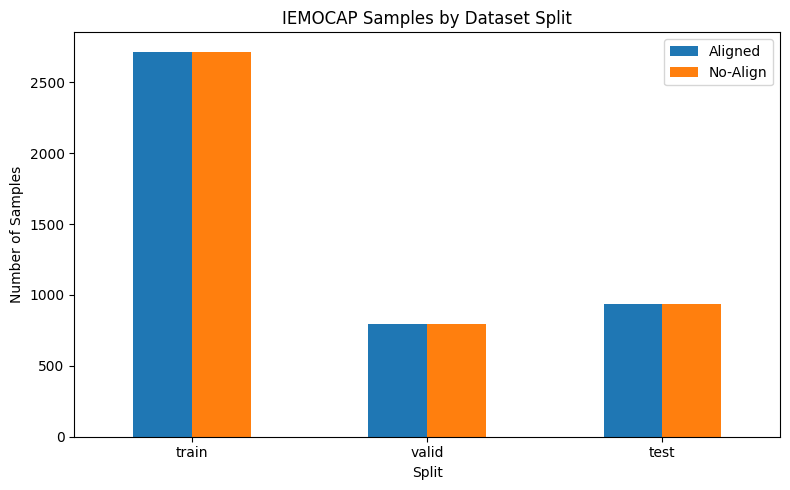

In [10]:
# ================================================================

print("\n" + "=" * 80)
print("SPLIT SIZE COMPARISON")
print("=" * 80)

size_rows = []

for split in ["train", "valid", "test"]:

    size_rows.append({
        "Split": split,
        "Aligned": split_size(
            aligned_data,
            split
        ),
        "No-Align": (
            split_size(noalign_data, split)
            if noalign_data is not None
            else None
        )
    })

split_df = pd.DataFrame(size_rows)

display(split_df)

plt.figure(figsize=(8, 5))

plot_df = split_df.set_index("Split")

plot_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("IEMOCAP Samples by Dataset Split")
plt.xlabel("Split")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Detect dataset splits

In [12]:
# ================================================================

aligned_train, aligned_train_name = get_split_data(
    aligned_data,
    "train"
)

aligned_valid, aligned_valid_name = get_split_data(
    aligned_data,
    "valid"
)

aligned_test, aligned_test_name = get_split_data(
    aligned_data,
    "test"
)

if aligned_train is None:
    raise ValueError(
        "Could not find a training split in the aligned pickle."
    )

print("\nDetected splits:")
print("Train:", aligned_train_name)
print("Valid:", aligned_valid_name)
print("Test :", aligned_test_name)


Detected splits:
Train: train
Valid: valid
Test : test


## 10. Emotion/label analysis


LABEL / EMOTION ANALYSIS
Detected label key: labels

Original label shape: (2717, 4, 2)
Original label dtype: int64

Structured labels detected: (2717, 4, 2)

Number of training labels: 2717
Processed label shape: (2717,)
Unique labels: [0 1]

Label counts:


,Count
0,1763
1,954



Label proportions:


,Proportion
0,0.648877
1,0.351123


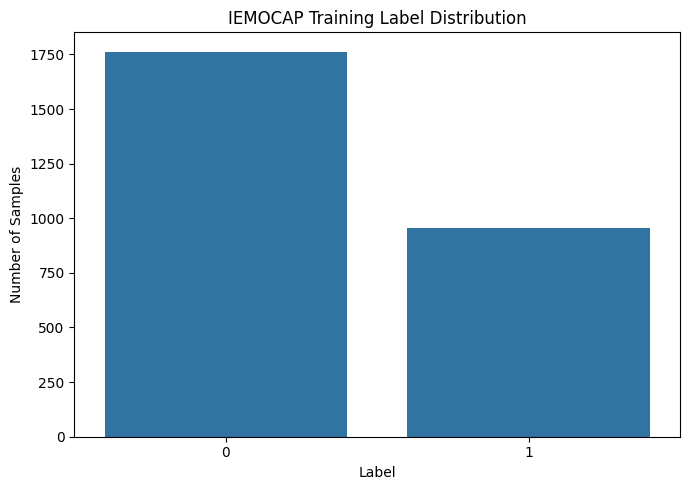

In [14]:
# ================================================================
# 10. EMOTION / LABEL ANALYSIS
# ================================================================

label_key = find_label_key(aligned_train)

print("\n" + "=" * 80)
print("LABEL / EMOTION ANALYSIS")
print("=" * 80)

print("Detected label key:", label_key)

if label_key is None:

    print("\nWARNING: Could not automatically detect a label key.")

    print(
        "Available train keys:",
        list(aligned_train.keys())
        if isinstance(aligned_train, dict)
        else type(aligned_train)
    )

else:

    # ------------------------------------------------------------
    # Inspect the ORIGINAL label structure
    # ------------------------------------------------------------

    raw_labels = np.asarray(
        aligned_train[label_key]
    )

    print("\nOriginal label shape:", raw_labels.shape)
    print("Original label dtype:", raw_labels.dtype)

    # ------------------------------------------------------------
    # Handle label structure
    # ------------------------------------------------------------

    if raw_labels.ndim == 1:

        y_train = raw_labels

    elif raw_labels.ndim == 2:

        if raw_labels.shape[1] == 1:
            y_train = raw_labels[:, 0]

        else:
            # One-hot / probability representation
            y_train = np.argmax(
                raw_labels,
                axis=1
            )

    elif raw_labels.ndim == 3:

        print(
            "\nStructured labels detected:",
            raw_labels.shape
        )

        # Keep the SAMPLE dimension intact.
        # For the current IEMOCAP structure (N, 4, 2),
        # use the first label position.
        y_train = np.argmax(
            raw_labels[:, 0, :],
            axis=1
        )

    else:

        raise ValueError(
            f"Unsupported label shape: {raw_labels.shape}"
        )

    # ------------------------------------------------------------
    # Final label information
    # ------------------------------------------------------------

    print(
        "\nNumber of training labels:",
        len(y_train)
    )

    print(
        "Processed label shape:",
        y_train.shape
    )

    print(
        "Unique labels:",
        np.unique(y_train)
    )

    # ------------------------------------------------------------
    # Label counts
    # ------------------------------------------------------------

    label_counts = pd.Series(
        y_train
    ).value_counts().sort_index()

    print("\nLabel counts:")

    display(
        label_counts.to_frame("Count")
    )

    # ------------------------------------------------------------
    # Label proportions
    # ------------------------------------------------------------

    label_proportions = (
        label_counts /
        label_counts.sum()
    )

    print("\nLabel proportions:")

    display(
        label_proportions.to_frame(
            "Proportion"
        )
    )

    # ------------------------------------------------------------
    # Visualization
    # ------------------------------------------------------------

    plt.figure(figsize=(7, 5))

    sns.barplot(
        x=label_counts.index.astype(str),
        y=label_counts.values
    )

    plt.title(
        "IEMOCAP Training Label Distribution"
    )

    plt.xlabel("Label")
    plt.ylabel("Number of Samples")

    plt.tight_layout()
    plt.show()


## 11. Missing-value analysis

In [15]:
# ================================================================

def missing_value_summary(split_data):
    rows = []

    if not isinstance(split_data, dict):
        return pd.DataFrame()

    for key, value in split_data.items():

        try:
            arr = np.asarray(value)

            nan_count = 0
            inf_count = 0

            if np.issubdtype(arr.dtype, np.number):
                nan_count = int(np.isnan(arr).sum())
                inf_count = int(np.isinf(arr).sum())

            rows.append({
                "Feature": key,
                "Shape": str(arr.shape),
                "NaN Count": nan_count,
                "Inf Count": inf_count
            })

        except Exception:
            rows.append({
                "Feature": key,
                "Shape": "Not array-like",
                "NaN Count": "N/A",
                "Inf Count": "N/A"
            })

    return pd.DataFrame(rows)


print("\n" + "=" * 80)
print("MISSING VALUE / NaN ANALYSIS")
print("=" * 80)

missing_df = missing_value_summary(
    aligned_train
)

display(missing_df)


MISSING VALUE / NaN ANALYSIS


,Feature,Shape,NaN Count,Inf Count
0,labels,"(2717, 4, 2)",0,0
1,text,"(2717, 20, 300)",0,0
2,audio,"(2717, 20, 74)",0,0
3,vision,"(2717, 20, 35)",0,0


## 12. Modality shapes

In [16]:
# ================================================================

def modality_shape_table(data, split="train"):

    split_data, actual_name = get_split_data(
        data,
        split
    )

    if split_data is None:
        return pd.DataFrame()

    modality_candidates = [
        "text",
        "raw_text",
        "text_bert",
        "bert",
        "audio",
        "vision",
        "visual",
        "acoustic",
        "linguistic"
    ]

    rows = []
    used = set()

    for candidate in modality_candidates:

        key = find_key(
            split_data,
            [candidate]
        )

        if key is None or key in used:
            continue

        used.add(key)

        value = split_data[key]

        rows.append({
            "Modality / Feature": key,
            "Type": type(value).__name__,
            "Shape": str(safe_shape(value)),
            "Number of samples": value_length(value)
        })

    return pd.DataFrame(rows)


print("\n" + "=" * 80)
print("ALIGNED MODALITY SHAPES")
print("=" * 80)

aligned_modalities = modality_shape_table(
    aligned_data,
    "train"
)

display(aligned_modalities)

if noalign_data is not None:

    print("\n" + "=" * 80)
    print("NO-ALIGN MODALITY SHAPES")
    print("=" * 80)

    noalign_modalities = modality_shape_table(
        noalign_data,
        "train"
    )

    display(noalign_modalities)


ALIGNED MODALITY SHAPES


,Modality / Feature,Type,Shape,Number of samples
0,text,ndarray,"(2717, 20, 300)",2717
1,audio,ndarray,"(2717, 20, 74)",2717
2,vision,ndarray,"(2717, 20, 35)",2717



NO-ALIGN MODALITY SHAPES


,Modality / Feature,Type,Shape,Number of samples
0,text,ndarray,"(2717, 20, 300)",2717
1,audio,ndarray,"(2717, 400, 74)",2717
2,vision,ndarray,"(2717, 500, 35)",2717


## 13. Aligned vs no-align sequence analysis

In [17]:
# ================================================================

def get_sequence_lengths(data, logical_split="train"):

    split_data, _ = get_split_data(
        data,
        logical_split
    )

    if split_data is None or not isinstance(split_data, dict):
        return {}

    result = {}

    for key, value in split_data.items():

        try:
            arr = np.asarray(value)

            # Sequence representation normally looks like:
            # (N, T, D)
            if arr.ndim >= 3:
                result[key] = {
                    "shape": arr.shape,
                    "sequence_length": arr.shape[1]
                }

        except Exception:
            pass

    return result


print("\n" + "=" * 80)
print("SEQUENCE LENGTH ANALYSIS")
print("=" * 80)

aligned_seq = get_sequence_lengths(
    aligned_data
)

print("\nAligned:")
for key, info in aligned_seq.items():
    print(
        f"{key}: shape={info['shape']} | "
        f"sequence length={info['sequence_length']}"
    )

if noalign_data is not None:

    noalign_seq = get_sequence_lengths(
        noalign_data
    )

    print("\nNo-align:")
    for key, info in noalign_seq.items():
        print(
            f"{key}: shape={info['shape']} | "
            f"sequence length={info['sequence_length']}"
        )


SEQUENCE LENGTH ANALYSIS

Aligned:
labels: shape=(2717, 4, 2) | sequence length=4
text: shape=(2717, 20, 300) | sequence length=20
audio: shape=(2717, 20, 74) | sequence length=20
vision: shape=(2717, 20, 35) | sequence length=20

No-align:
labels: shape=(2717, 4, 2) | sequence length=4
text: shape=(2717, 20, 300) | sequence length=20
audio: shape=(2717, 400, 74) | sequence length=400
vision: shape=(2717, 500, 35) | sequence length=500


## 14. Basic text EDA


TEXT EDA
Detected text key: text

Number of text samples: 2717
Average words per sample: 52.24
Median words per sample: 53.0
Minimum words: 43
Maximum words: 55
Average characters: 416.71


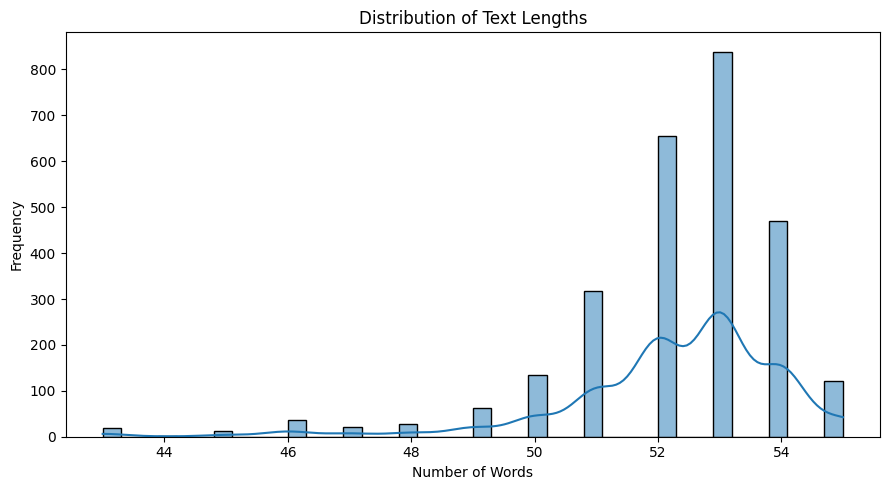


Sample text examples:
1. [[-0.084961   0.502      0.0023823 ... -0.21511   -0.26304   -0.0060173]
 [ 0.030971   0.24589   -0.2484    ... -0.23329    0.11165    0.088833 ]
 [-0.36556   -0.095359  -0.14092   ...  0.019754   0.29646    0.025029 ]
 ...
 [ 0.10231    0.2774    -0.057097  ... -0.31888    0.2366    -0.15062  ]
 [ 0.18733    0.40595   -0.51174   ...  0.16495    0.18757    0.53874  ]
 [ 0.088915   0.10855   -0.19835   ...  0.015445   0.25931    0.37895  ]]
2. [[ 0.        0.        0.       ...  0.        0.        0.      ]
 [ 0.        0.        0.       ...  0.        0.        0.      ]
 [ 0.        0.        0.       ...  0.        0.        0.      ]
 ...
 [-0.13563   0.33217  -0.3602   ... -0.17296   0.21676   0.22206 ]
 [ 0.09852   0.25001  -0.27018  ... -0.062639  0.24424   0.17779 ]
 [-0.48037   0.14215  -0.45985  ...  0.044432  0.25162  -0.10527 ]]
3. [[-1.8417e-01  5.5115e-02 -3.6953e-01 ... -2.3808e-01  3.7132e-01
   3.6197e-01]
 [-3.1870e-01  4.0069e-01  7.4904e-

In [18]:
# ================================================================

text_key = find_text_key(aligned_train)

print("\n" + "=" * 80)
print("TEXT EDA")
print("=" * 80)

print("Detected text key:", text_key)

raw_text_available = (
    text_key is not None
)

if raw_text_available:

    train_text = clean_text_array(
        aligned_train[text_key]
    )

    # Basic text statistics
    word_counts = np.array([
        len(text.split())
        for text in train_text
    ])

    character_counts = np.array([
        len(text)
        for text in train_text
    ])

    print("\nNumber of text samples:", len(train_text))

    print(
        "Average words per sample:",
        round(word_counts.mean(), 2)
    )

    print(
        "Median words per sample:",
        round(np.median(word_counts), 2)
    )

    print(
        "Minimum words:",
        word_counts.min()
    )

    print(
        "Maximum words:",
        word_counts.max()
    )

    print(
        "Average characters:",
        round(character_counts.mean(), 2)
    )

    # Text length distribution
    plt.figure(figsize=(9, 5))

    sns.histplot(
        word_counts,
        bins=40,
        kde=True
    )

    plt.title("Distribution of Text Lengths")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # Show examples
    print("\nSample text examples:")

    for i in range(min(10, len(train_text))):
        print(
            f"{i + 1}. {train_text[i]}"
        )

else:

    print(
        "\nNo raw text column was automatically detected."
    )

    print(
        "The classifier section will try a numeric text-feature "
        "fallback if such features exist."
    )

## 15. Text length vs emotion

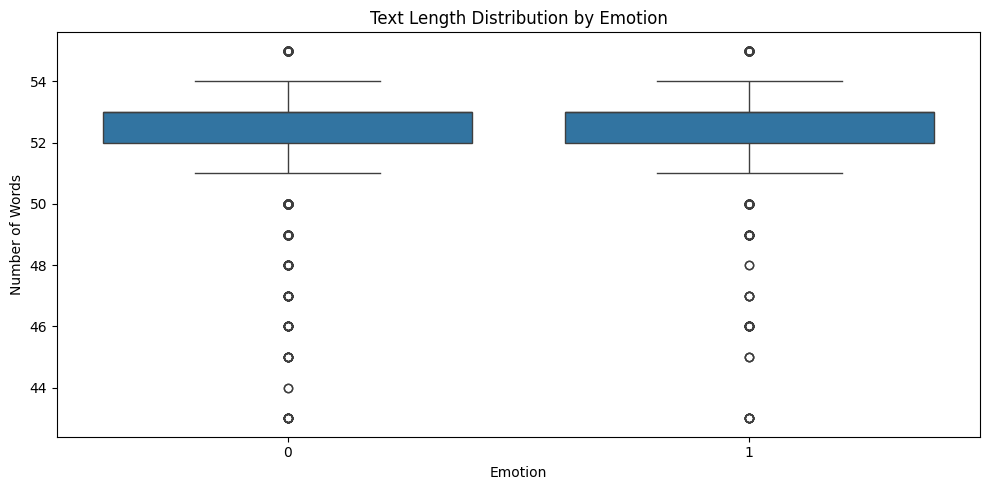

In [19]:
# ================================================================

if raw_text_available and label_key is not None:

    if len(train_text) == len(y_train):

        text_length_df = pd.DataFrame({
            "Emotion": y_train.astype(str),
            "Word_Count": word_counts
        })

        plt.figure(figsize=(10, 5))

        sns.boxplot(
            data=text_length_df,
            x="Emotion",
            y="Word_Count"
        )

        plt.title(
            "Text Length Distribution by Emotion"
        )

        plt.xlabel("Emotion")
        plt.ylabel("Number of Words")
        plt.tight_layout()
        plt.show()

## 16. Quick emotion classifier


QUICK EMOTION CLASSIFIER

Train labels original shape: (2717, 4, 2)
Train labels: structured 3D labels detected.
Train labels processed shape: (2717,)
Train labels unique classes: [0 1]

Validation labels original shape: (798, 4, 2)
Validation labels: structured 3D labels detected.
Validation labels processed shape: (798,)
Validation labels unique classes: [0 1]

Test labels original shape: (938, 4, 2)
Test labels: structured 3D labels detected.
Test labels processed shape: (938,)
Test labels unique classes: [0 1]

Detected text keys:
Train: text
Validation: text
Test: text

Length check:
Train: 2717 texts | 2717 labels
Validation: 798 texts | 798 labels
Test: 938 texts | 938 labels

Using classifier:
Raw text -> TF-IDF -> Logistic Regression

TF-IDF shapes:
Train: (2717, 5000)
Validation: (798, 5000)
Test: (938, 5000)

Classifier trained successfully.

------------------------------------------------------------
CLASSIFIER RESULTS
-----------------------------------------------------

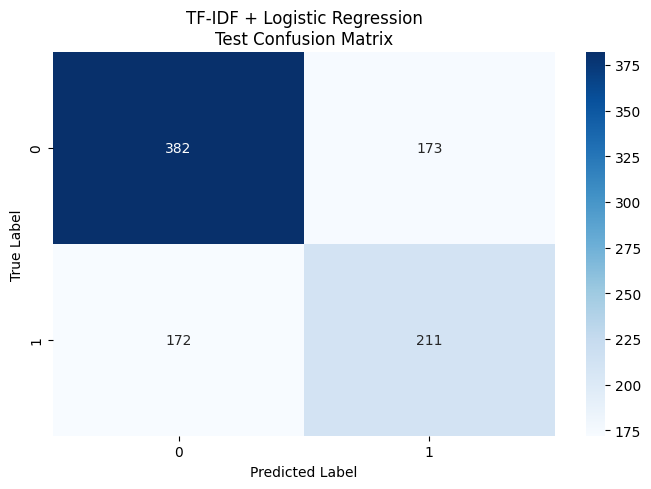

In [22]:
# ================================================================
# QUICK EMOTION CLASSIFIER
# Raw text -> TF-IDF -> Logistic Regression
# ================================================================

print("\n" + "=" * 80)
print("QUICK EMOTION CLASSIFIER")
print("=" * 80)

classifier = None
vectorizer = None
classifier_mode = None
feature_key = None


# ------------------------------------------------------------
# Helper: convert labels to one class per sample
# ------------------------------------------------------------

def prepare_classifier_labels(labels, name="labels"):

    arr = np.asarray(labels)

    print(f"\n{name} original shape: {arr.shape}")

    if arr.ndim == 1:

        y = arr

    elif arr.ndim == 2:

        if arr.shape[1] == 1:
            y = arr[:, 0]

        else:
            # One-hot representation
            y = np.argmax(arr, axis=1)

    elif arr.ndim == 3:

        print(
            f"{name}: structured 3D labels detected."
        )

        # Current dataset structure:
        # (N, 4, 2)
        #
        # Keep N = number of samples.
        # Convert the 2-class representation
        # into one class ID per sample.

        if arr.shape[-1] == 2:

            y = np.argmax(
                arr[:, 0, :],
                axis=1
            )

        else:

            raise ValueError(
                f"Unsupported 3D label shape: {arr.shape}"
            )

    else:

        raise ValueError(
            f"Unsupported label shape: {arr.shape}"
        )

    y = np.asarray(y).reshape(-1)

    print(
        f"{name} processed shape: {y.shape}"
    )

    print(
        f"{name} unique classes: {np.unique(y)}"
    )

    return y


# ------------------------------------------------------------
# Check that train/validation/test splits exist
# ------------------------------------------------------------

if (
    label_key is not None
    and aligned_train is not None
    and aligned_valid is not None
    and aligned_test is not None
):

    # --------------------------------------------------------
    # 1. Prepare labels
    # --------------------------------------------------------

    y_train = prepare_classifier_labels(
        aligned_train[label_key],
        "Train labels"
    )

    y_valid = prepare_classifier_labels(
        aligned_valid[label_key],
        "Validation labels"
    )

    y_test = prepare_classifier_labels(
        aligned_test[label_key],
        "Test labels"
    )


    # --------------------------------------------------------
    # 2. Find text fields
    # --------------------------------------------------------

    train_text_key = find_text_key(
        aligned_train
    )

    valid_text_key = find_text_key(
        aligned_valid
    )

    test_text_key = find_text_key(
        aligned_test
    )

    print("\nDetected text keys:")

    print(
        "Train:",
        train_text_key
    )

    print(
        "Validation:",
        valid_text_key
    )

    print(
        "Test:",
        test_text_key
    )


    # --------------------------------------------------------
    # 3. Raw text -> TF-IDF
    # --------------------------------------------------------

    if (
        train_text_key is not None
        and valid_text_key is not None
        and test_text_key is not None
    ):

        X_train_text = clean_text_array(
            aligned_train[train_text_key]
        )

        X_valid_text = clean_text_array(
            aligned_valid[valid_text_key]
        )

        X_test_text = clean_text_array(
            aligned_test[test_text_key]
        )


        # ----------------------------------------------------
        # Check lengths
        # ----------------------------------------------------

        print("\nLength check:")

        print(
            "Train:",
            len(X_train_text),
            "texts |",
            len(y_train),
            "labels"
        )

        print(
            "Validation:",
            len(X_valid_text),
            "texts |",
            len(y_valid),
            "labels"
        )

        print(
            "Test:",
            len(X_test_text),
            "texts |",
            len(y_test),
            "labels"
        )


        if (
            len(X_train_text) == len(y_train)
            and
            len(X_valid_text) == len(y_valid)
            and
            len(X_test_text) == len(y_test)
        ):

            print(
                "\nUsing classifier:"
                "\nRaw text -> TF-IDF -> Logistic Regression"
            )


            # ------------------------------------------------
            # TF-IDF
            # ------------------------------------------------

            vectorizer = TfidfVectorizer(
                max_features=5000,
                ngram_range=(1, 2),
                min_df=2,
                sublinear_tf=True
            )

            X_train = vectorizer.fit_transform(
                X_train_text
            )

            X_valid = vectorizer.transform(
                X_valid_text
            )

            X_test = vectorizer.transform(
                X_test_text
            )


            print("\nTF-IDF shapes:")

            print(
                "Train:",
                X_train.shape
            )

            print(
                "Validation:",
                X_valid.shape
            )

            print(
                "Test:",
                X_test.shape
            )


            # ------------------------------------------------
            # Logistic Regression
            # ------------------------------------------------

            classifier = LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )

            classifier.fit(
                X_train,
                y_train
            )

            classifier_mode = "tfidf"

            print(
                "\nClassifier trained successfully."
            )


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            y_valid_pred = classifier.predict(
                X_valid
            )

            y_test_pred = classifier.predict(
                X_test
            )


            # ------------------------------------------------
            # Accuracy
            # ------------------------------------------------

            valid_accuracy = accuracy_score(
                y_valid,
                y_valid_pred
            )

            test_accuracy = accuracy_score(
                y_test,
                y_test_pred
            )

            print("\n" + "-" * 60)
            print("CLASSIFIER RESULTS")
            print("-" * 60)

            print(
                f"Validation Accuracy: {valid_accuracy:.4f}"
            )

            print(
                f"Test Accuracy:       {test_accuracy:.4f}"
            )


            # ------------------------------------------------
            # Classification report
            # ------------------------------------------------

            print(
                "\nTest Classification Report:"
            )

            print(
                classification_report(
                    y_test,
                    y_test_pred,
                    zero_division=0
                )
            )


            # ------------------------------------------------
            # Confusion Matrix
            # ------------------------------------------------

            cm = confusion_matrix(
                y_test,
                y_test_pred
            )

            plt.figure(
                figsize=(7, 5)
            )

            sns.heatmap(
                cm,
                annot=True,
                fmt="d",
                cmap="Blues"
            )

            plt.title(
                "TF-IDF + Logistic Regression\nTest Confusion Matrix"
            )

            plt.xlabel(
                "Predicted Label"
            )

            plt.ylabel(
                "True Label"
            )

            plt.tight_layout()
            plt.show()


        else:

            print(
                "\nERROR: Text and label lengths do not match."
            )

    else:

        print(
            "\nRaw text keys could not be detected."
        )

else:

    print(
        "\nCannot train classifier because "
        "train/validation/test splits or labels are missing."
    )

## 17. Validation evaluation

In [23]:
# ================================================================

if classifier is not None:

    print("\n" + "=" * 80)
    print("VALIDATION RESULTS")
    print("=" * 80)

    y_valid_pred = classifier.predict(
        X_valid
    )

    valid_accuracy = accuracy_score(
        y_valid,
        y_valid_pred
    )

    valid_f1 = f1_score(
        y_valid,
        y_valid_pred,
        average="weighted"
    )

    print(
        f"Validation Accuracy: {valid_accuracy:.4f}"
    )

    print(
        f"Validation Weighted F1: {valid_f1:.4f}"
    )

    print("\nValidation Classification Report:")

    print(
        classification_report(
            y_valid,
            y_valid_pred,
            zero_division=0
        )
    )


VALIDATION RESULTS
Validation Accuracy: 0.6228
Validation Weighted F1: 0.6219

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.68      0.66       440
           1       0.58      0.56      0.57       358

    accuracy                           0.62       798
   macro avg       0.62      0.62      0.62       798
weighted avg       0.62      0.62      0.62       798



## 18. Test evaluation

In [24]:
# ================================================================

if classifier is not None:

    print("\n" + "=" * 80)
    print("TEST RESULTS")
    print("=" * 80)

    y_test_pred = classifier.predict(
        X_test
    )

    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )

    test_f1 = f1_score(
        y_test,
        y_test_pred,
        average="weighted"
    )

    print(
        f"Test Accuracy: {test_accuracy:.4f}"
    )

    print(
        f"Test Weighted F1: {test_f1:.4f}"
    )

    print("\nTest Classification Report:")

    print(
        classification_report(
            y_test,
            y_test_pred,
            zero_division=0
        )
    )


TEST RESULTS
Test Accuracy: 0.6322
Test Weighted F1: 0.6323

Test Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.69      0.69       555
           1       0.55      0.55      0.55       383

    accuracy                           0.63       938
   macro avg       0.62      0.62      0.62       938
weighted avg       0.63      0.63      0.63       938



## 19. Confusion matrix

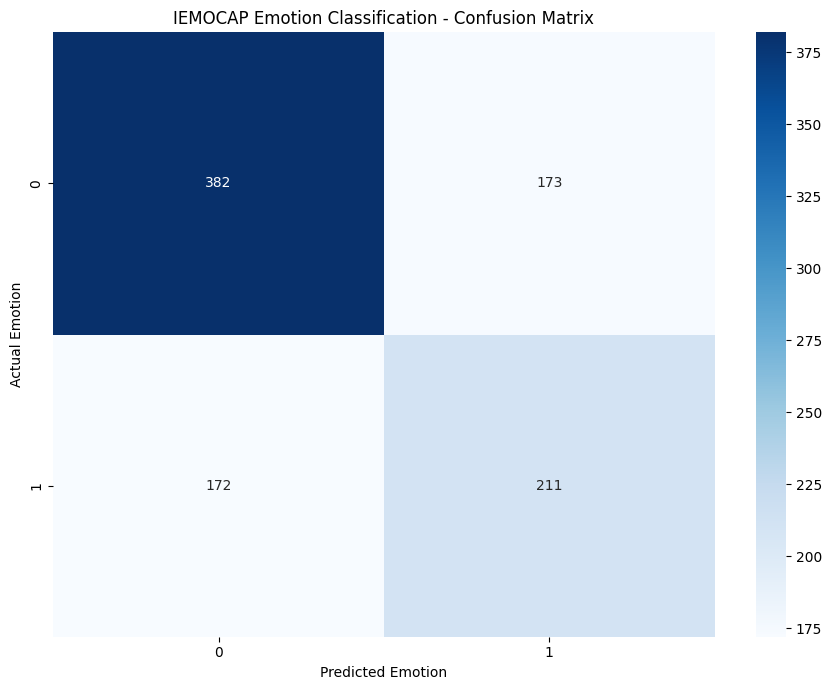

In [25]:
# ================================================================

if classifier is not None:

    cm = confusion_matrix(
        y_test,
        y_test_pred
    )

    class_names = np.unique(
        np.concatenate([
            np.asarray(y_test),
            np.asarray(y_test_pred)
        ])
    )

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(
        "IEMOCAP Emotion Classification - Confusion Matrix"
    )

    plt.xlabel(
        "Predicted Emotion"
    )

    plt.ylabel(
        "Actual Emotion"
    )

    plt.tight_layout()
    plt.show()

## 20. Results summary

In [26]:
# ================================================================

if classifier is not None:

    results_df = pd.DataFrame({
        "Metric": [
            "Validation Accuracy",
            "Validation Weighted F1",
            "Test Accuracy",
            "Test Weighted F1"
        ],
        "Score": [
            valid_accuracy,
            valid_f1,
            test_accuracy,
            test_f1
        ]
    })

    print("\n" + "=" * 80)
    print("FINAL CLASSIFIER RESULTS")
    print("=" * 80)

    display(
        results_df.style.format({
            "Score": "{:.4f}"
        })
    )


FINAL CLASSIFIER RESULTS


,Metric,Score
0,Validation Accuracy,0.6228
1,Validation Weighted F1,0.6219
2,Test Accuracy,0.6322
3,Test Weighted F1,0.6323


## 21. Inference function

In [27]:
# ================================================================

def predict_emotion(text):
    """
    Predict an emotion for a new sentence.

    Works for:
    1. TF-IDF + Logistic Regression
    2. Numeric text representation + Logistic Regression
       if a raw-text vectorizer is not available.
    """

    if classifier is None:
        raise RuntimeError(
            "Classifier was not trained successfully."
        )

    if classifier_mode == "tfidf":

        text_vector = vectorizer.transform(
            [str(text)]
        )

        prediction = classifier.predict(
            text_vector
        )[0]

        probabilities = classifier.predict_proba(
            text_vector
        )[0]

        classes = classifier.classes_

        probability_df = pd.DataFrame({
            "Emotion": classes,
            "Probability": probabilities
        }).sort_values(
            "Probability",
            ascending=False
        ).reset_index(drop=True)

        return prediction, probability_df

    raise RuntimeError(
        "Raw text inference is not available because "
        "the pickle did not contain raw text."
    )

## 22. Sample inference

In [28]:
# ================================================================

if classifier is not None and classifier_mode == "tfidf":

    print("\n" + "=" * 80)
    print("SAMPLE INFERENCE")
    print("=" * 80)

    sample_sentences = [
        "I am really happy that everything worked out.",
        "I cannot believe you did this to me. I am extremely angry.",
        "I feel so sad and disappointed about what happened.",
        "This is frightening and I do not know what to do.",
        "I am surprised that you actually came."
    ]

    for sentence in sample_sentences:

        prediction, probabilities = predict_emotion(
            sentence
        )

        print("\nInput:")
        print(sentence)

        print(
            "\nPredicted emotion:",
            prediction
        )

        print(
            "Top probabilities:"
        )

        display(
            probabilities.head(5)
        )


SAMPLE INFERENCE

Input:
I am really happy that everything worked out.

Predicted emotion: 1
Top probabilities:


,Emotion,Probability
0,1,0.511556
1,0,0.488444



Input:
I cannot believe you did this to me. I am extremely angry.

Predicted emotion: 1
Top probabilities:


,Emotion,Probability
0,1,0.511556
1,0,0.488444



Input:
I feel so sad and disappointed about what happened.

Predicted emotion: 1
Top probabilities:


,Emotion,Probability
0,1,0.511556
1,0,0.488444



Input:
This is frightening and I do not know what to do.

Predicted emotion: 1
Top probabilities:


,Emotion,Probability
0,1,0.511556
1,0,0.488444



Input:
I am surprised that you actually came.

Predicted emotion: 1
Top probabilities:


,Emotion,Probability
0,1,0.511556
1,0,0.488444


## 23. Custom inference

In [29]:
# ================================================================

if classifier is not None and classifier_mode == "tfidf":

    print("\n" + "=" * 80)
    print("CUSTOM INFERENCE")
    print("=" * 80)

    custom_text = input(
        "Enter a sentence to classify "
        "(or press Enter to skip): "
    )

    if custom_text.strip():

        prediction, probabilities = predict_emotion(
            custom_text
        )

        print(
            "\nPredicted Emotion:",
            prediction
        )

        print(
            "\nProbability Distribution:"
        )

        display(probabilities)


CUSTOM INFERENCE
Enter a sentence to classify (or press Enter to skip): SATWIKA IS GREAT

Predicted Emotion: 1

Probability Distribution:


,Emotion,Probability
0,1,0.511556
1,0,0.488444


## 24. Aligned vs no-align interpretation

In [30]:
# ================================================================

print("\n" + "=" * 80)
print("ALIGNED VS NO-ALIGN INTERPRETATION")
print("=" * 80)

print(
    """
ALIGNED DATA
------------
The modalities are represented so that their temporal information
is synchronized/aligned. This makes corresponding text, audio and
visual representations easier to associate at matching positions.

NO-ALIGN DATA
-------------
The modalities retain their own temporal/sequence representation.
Different modalities may therefore have different sequence lengths
or temporal resolutions.

WHY THIS MATTERS
----------------
For multimodal emotion recognition, alignment determines how easily
information from text, audio and vision can be combined at the same
time step. An aligned representation is convenient for direct
cross-modal comparison, while an unaligned representation can retain
more modality-specific temporal information.
"""
)


ALIGNED VS NO-ALIGN INTERPRETATION

ALIGNED DATA
------------
The modalities are represented so that their temporal information
is synchronized/aligned. This makes corresponding text, audio and
visual representations easier to associate at matching positions.

NO-ALIGN DATA
-------------
The modalities retain their own temporal/sequence representation.
Different modalities may therefore have different sequence lengths
or temporal resolutions.

WHY THIS MATTERS
----------------
For multimodal emotion recognition, alignment determines how easily
information from text, audio and vision can be combined at the same
time step. An aligned representation is convenient for direct
cross-modal comparison, while an unaligned representation can retain
more modality-specific temporal information.



## 25. Final summary

In [31]:
# ================================================================

print("\n" + "=" * 80)
print("ANALYSIS COMPLETED")
print("=" * 80)

print(
    """
Completed workflow:

1. Loaded the existing IEMOCAP pickle files.
2. Inspected the pickle structure.
3. Displayed keys/features, shapes and data types.
4. Calculated basic numerical statistics.
5. Checked NaN/Inf values.
6. Analysed train/validation/test split sizes.
7. Analysed emotion/class distribution.
8. Analysed text length when raw text was available.
9. Compared aligned and no-align representations.
10. Trained a quick Logistic Regression baseline.
11. Evaluated using accuracy, weighted F1 and classification report.
12. Generated a confusion matrix.
13. Performed inference on new sentences when raw text was available.
14. Added PCA visualizations for text, audio and vision.
15. Compared aligned and no-align feature spaces, dimensions and sequence lengths.
16. Added feature magnitude, quality and percentage-based emotion visualizations.

IMPORTANT:
This is a QUICK BASELINE, not the final multimodal IEMOCAP model.
The classifier uses text only when raw text is available. The
aligned/no-align multimodal representations are analysed separately.
"""
)

print("\nDone.")


ANALYSIS COMPLETED

Completed workflow:

1. Loaded the existing IEMOCAP pickle files.
2. Inspected the pickle structure.
3. Displayed keys/features, shapes and data types.
4. Calculated basic numerical statistics.
5. Checked NaN/Inf values.
6. Analysed train/validation/test split sizes.
7. Analysed emotion/class distribution.
8. Analysed text length when raw text was available.
9. Compared aligned and no-align representations.
10. Trained a quick Logistic Regression baseline.
11. Evaluated using accuracy, weighted F1 and classification report.
12. Generated a confusion matrix.
13. Performed inference on new sentences when raw text was available.
14. Added PCA visualizations for text, audio and vision.
15. Compared aligned and no-align feature spaces, dimensions and sequence lengths.
16. Added feature magnitude, quality and percentage-based emotion visualizations.

IMPORTANT:
This is a QUICK BASELINE, not the final multimodal IEMOCAP model.
The classifier uses text only when raw text i

## Additional visual EDA — PCA, dimensions, feature distributions and alignment

This section is visualization-only and does not modify the supplied pickle files.


In [32]:
# ================================================================
# ADDITIONAL VISUAL EDA: PCA, DIMENSIONS, QUALITY, ALIGNMENT
# ================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def find_modality(obj, modality):
    if not isinstance(obj, dict): return None,None
    keys=list(obj.keys()); low={str(k).lower():k for k in keys}
    candidates={"text":["text","text_data","text_features","text_bert"],"audio":["audio","audio_data","audio_features"],"vision":["vision","visual","visual_data","visual_features"]}[modality]
    for x in candidates:
        if x in low: return low[x],obj[low[x]]
    for k in keys:
        z=str(k).lower()
        if modality=="text" and "text" in z: return k,obj[k]
        if modality=="audio" and ("audio" in z or "acoustic" in z): return k,obj[k]
        if modality=="vision" and ("vision" in z or "visual" in z): return k,obj[k]
    return None,None

def flatten_sample(x):
    a=np.asarray(x)
    if a.dtype==object: return None
    if a.ndim==3: return np.nanmean(a.astype(float),axis=1)
    if a.ndim==2: return a.astype(float)
    if a.ndim==1: return a.reshape(-1,1).astype(float)
    return None

def get_labels(obj):
    if not isinstance(obj,dict): return None
    for k in obj:
        if str(k).lower() in ["label","labels","emotion","emotion_label","y"]:
            v=obj[k]
            if isinstance(v,dict):
                parts=[]
                for sk in v:
                    if str(sk).lower() in ["train","valid","val","test"]:
                        a=np.asarray(v[sk]); parts.append(a.reshape(-1))
                if parts: return np.concatenate(parts)
            try: return np.asarray(v).reshape(-1)
            except: pass
    return None

# 1. Dimensions and sequence lengths
rows=[]
for name,obj in [("Aligned",aligned_data),("No-align",noalign_data)]:
    if obj is None: continue
    for mod in ["text","audio","vision"]:
        key,v=find_modality(obj,mod)
        if v is None: continue
        try: a=np.asarray(v)
        except: continue
        if a.dtype==object: continue
        rows.append({"Dataset":name,"Modality":mod.title(),"Key":str(key),"Samples":a.shape[0],"Sequence_Length":a.shape[1] if a.ndim==3 else 1,"Feature_Dimension":a.shape[-1] if a.ndim>=2 else 1,"Shape":str(a.shape)})
dim_df=pd.DataFrame(rows)
if not dim_df.empty:
 display(dim_df); dim_df.to_csv(os.path.join(OUTPUT_DIR,"01_modality_dimensions.csv"),index=False)
 plt.figure(figsize=(9,5)); sns.barplot(data=dim_df,x="Modality",y="Feature_Dimension",hue="Dataset"); plt.title("Feature Dimension: Aligned vs No-align"); plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"01_feature_dimension_comparison.png"),dpi=200); plt.show()
 plt.figure(figsize=(9,5)); sns.barplot(data=dim_df,x="Modality",y="Sequence_Length",hue="Dataset"); plt.title("Sequence Length: Aligned vs No-align"); plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"02_sequence_length_comparison.png"),dpi=200); plt.show()

# 2. Feature magnitude comparison
rows=[]
for name,obj in [("Aligned",aligned_data),("No-align",noalign_data)]:
 if obj is None: continue
 for mod in ["text","audio","vision"]:
  _,v=find_modality(obj,mod)
  if v is None: continue
  try: vals=np.asarray(v,dtype=float); vals=vals[np.isfinite(vals)]
  except: continue
  if len(vals): rows.append({"Dataset":name,"Modality":mod.title(),"Mean":vals.mean(),"Std":vals.std(),"Mean_Absolute":np.abs(vals).mean(),"Min":vals.min(),"Max":vals.max()})
mag_df=pd.DataFrame(rows)
if not mag_df.empty:
 display(mag_df); mag_df.to_csv(os.path.join(OUTPUT_DIR,"02_feature_magnitude_statistics.csv"),index=False)
 plt.figure(figsize=(9,5)); sns.barplot(data=mag_df,x="Modality",y="Mean_Absolute",hue="Dataset"); plt.title("Mean Absolute Feature Magnitude"); plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"03_feature_magnitude_comparison.png"),dpi=200); plt.show()

# 3. PCA per modality, emotion-aware when labels match
pca_rows=[]
for name,obj in [("Aligned",aligned_data),("No-align",noalign_data)]:
 if obj is None: continue
 labels=get_labels(obj)
 for mod in ["text","audio","vision"]:
  _,v=find_modality(obj,mod); X=flatten_sample(v) if v is not None else None
  if X is None or len(X)<3: continue
  good=np.isfinite(X).all(axis=1); X=X[good]; y=labels[good] if labels is not None and len(labels)==len(good) else None
  rng=np.random.default_rng(42)
  if len(X)>2500:
   ix=rng.choice(len(X),2500,replace=False); X=X[ix]; y=y[ix] if y is not None else None
  keep=np.std(X,axis=0)>0; X=X[:,keep]
  if X.shape[1]<2: continue
  Z=PCA(n_components=2,random_state=42).fit_transform(StandardScaler().fit_transform(X))
  p=PCA(n_components=2,random_state=42); Z=p.fit_transform(StandardScaler().fit_transform(X))
  pca_rows.append({"Dataset":name,"Modality":mod.title(),"Samples_Used":len(X),"PC1_Variance":p.explained_variance_ratio_[0],"PC2_Variance":p.explained_variance_ratio_[1],"PC1_PC2_Total":p.explained_variance_ratio_.sum()})
  plt.figure(figsize=(8,6))
  if y is not None and len(np.unique(y))>1: sns.scatterplot(x=Z[:,0],y=Z[:,1],hue=pd.Series(y).astype(str),s=24,alpha=.6,legend=True); plt.legend(title="Emotion",bbox_to_anchor=(1.02,1),loc="upper left")
  else: plt.scatter(Z[:,0],Z[:,1],s=20,alpha=.5)
  plt.title(f"{name} — {mod.title()} PCA | PC1 {p.explained_variance_ratio_[0]*100:.1f}% + PC2 {p.explained_variance_ratio_[1]*100:.1f}%"); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,f"04_PCA_{name.lower().replace('-','_')}_{mod}.png"),dpi=200,bbox_inches="tight"); plt.show()
pca_df=pd.DataFrame(pca_rows)
if not pca_df.empty: display(pca_df); pca_df.to_csv(os.path.join(OUTPUT_DIR,"03_PCA_summary.csv"),index=False)

# 4. Direct aligned vs no-align PCA comparison
if noalign_data is not None:
 for mod in ["text","audio","vision"]:
  _,va=find_modality(aligned_data,mod); _,vn=find_modality(noalign_data,mod); Xa=flatten_sample(va) if va is not None else None; Xn=flatten_sample(vn) if vn is not None else None
  if Xa is None or Xn is None: continue
  n=min(len(Xa),len(Xn),1500); d=min(Xa.shape[1],Xn.shape[1]); Xa=Xa[:n,:d]; Xn=Xn[:n,:d]; Xa=Xa[np.isfinite(Xa).all(axis=1)]; Xn=Xn[np.isfinite(Xn).all(axis=1)]; n=min(len(Xa),len(Xn))
  if n<3 or d<2: continue
  X=np.vstack([Xa[:n],Xn[:n]]); groups=np.array(["Aligned"]*n+["No-align"]*n); X=X[:,np.std(X,axis=0)>0]
  if X.shape[1]<2: continue
  Z=PCA(n_components=2,random_state=42).fit_transform(StandardScaler().fit_transform(X))
  plt.figure(figsize=(8,6)); sns.scatterplot(x=Z[:,0],y=Z[:,1],hue=groups,s=25,alpha=.55); plt.title(f"Aligned vs No-align PCA — {mod.title()}"); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,f"05_aligned_vs_noalign_PCA_{mod}.png"),dpi=200); plt.show()

# 5. Emotion percentages
for name,obj in [("Aligned",aligned_data),("No-align",noalign_data)]:
 if obj is None: continue
 labels=get_labels(obj)
 if labels is None: continue
 c=pd.Series(labels).astype(str).value_counts().sort_index(); df=pd.DataFrame({"Emotion":c.index,"Count":c.values,"Percentage":c.values/c.sum()*100}); display(df); df.to_csv(os.path.join(OUTPUT_DIR,f"06_{name.lower().replace('-','_')}_emotion_distribution.csv"),index=False)
 plt.figure(figsize=(9,5)); ax=sns.barplot(x=df.Emotion,y=df.Percentage); plt.title(f"{name} Emotion Distribution (%)"); plt.ylabel("Percentage"); plt.xticks(rotation=45); [ax.bar_label(x,fmt="%.1f%%",padding=3) for x in ax.containers]; plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,f"06_{name.lower().replace('-','_')}_emotion_distribution.png"),dpi=200); plt.show()

print("Additional visual EDA complete. Outputs saved to:",OUTPUT_DIR)


Additional visual EDA complete. Outputs saved to: /content/drive/MyDrive/mplmm_final_deliverables/outputs/IEMOCAP
